In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import process_data

/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import process_data

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(parent_dir)
interpolated_dir = os.path.join(parent_dir, "dataset_interpolated_fixed")
features = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.down", "end.distance", "end.yardsToEndzone", "home_timeouts_left", "away_timeouts_left", "predicted_drive_points_ev"]

/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML


In [60]:
modules_to_reload = [
    'process_data',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]
import process_data

training_data = process_data.load_data(interpolated_dir, 
                                       years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023], 
                                       history_length = 0, 
                                       features = features, 
                                       label_feature = "home_win"
                                       )

test_data = process_data.load_data(interpolated_dir, 
                                       years = [2024, 2025],
                                       history_length = 0, 
                                       features = features, 
                                       label_feature = "home_win",
                                       train = False
                                       )

Loading data for 2022
  Processing 271 CSV files in parallel with 8 workers...
  Completed processing 2022
Loading data for 2025
skipping  2025
Loading data for 2024
skipping  2024
Loading data for 2023
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2023
Loading data for .DS_Store
Loading data for 2017
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2017
Loading data for 2019
  Processing 256 CSV files in parallel with 8 workers...
  Completed processing 2019
Loading data for 2021
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2021
Loading data for 2020
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2020
Loading data for 2018
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2018
Loading data for 2016
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2016
Loading data for 2022
skipping  2022
Loadin

In [9]:
training_data.keys()

dict_keys([0.0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1, 0.105, 0.11, 0.115, 0.12, 0.125, 0.13, 0.135, 0.14, 0.145, 0.15, 0.155, 0.16, 0.165, 0.17, 0.175, 0.18, 0.185, 0.19, 0.195, 0.2, 0.205, 0.21, 0.215, 0.22, 0.225, 0.23, 0.235, 0.24, 0.245, 0.25, 0.255, 0.26, 0.265, 0.27, 0.275, 0.28, 0.285, 0.29, 0.295, 0.3, 0.305, 0.31, 0.315, 0.32, 0.325, 0.33, 0.335, 0.34, 0.345, 0.35, 0.355, 0.36, 0.365, 0.37, 0.375, 0.38, 0.385, 0.39, 0.395, 0.4, 0.405, 0.41, 0.415, 0.42, 0.425, 0.43, 0.435, 0.44, 0.445, 0.45, 0.455, 0.46, 0.465, 0.47, 0.475, 0.48, 0.485, 0.49, 0.495, 0.5, 0.505, 0.51, 0.515, 0.52, 0.525, 0.53, 0.535, 0.54, 0.545, 0.55, 0.555, 0.56, 0.565, 0.57, 0.575, 0.58, 0.585, 0.59, 0.595, 0.6, 0.605, 0.61, 0.615, 0.62, 0.625, 0.63, 0.635, 0.64, 0.645, 0.65, 0.655, 0.66, 0.665, 0.67, 0.675, 0.68, 0.685, 0.69, 0.695, 0.7, 0.705, 0.71, 0.715, 0.72, 0.725, 0.73, 0.735, 0.74, 0.745, 0.75, 0.755, 0.76, 0.7

In [61]:
modules_to_reload = [
    'models.xg_boost',
    'models.Model'
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]
import process_data

from models.xg_boost import setup_xgboost_models
from models.light_gbm import setup_lightgbm_models
other_features = [
            "home_has_possession", # Binary indicator
            "end.down",            # Down number (1-4, discrete)
            "home_timeouts_left",  # Discrete count (0-3)
            "away_timeouts_left",  # Discrete count (0-3)
            "score_difference",
        ]
numeric_features = [
    "game_completed",
    "relative_strength", 
    "end.yardsToEndzone", 
    "end.distance",
    "predicted_drive_points_ev"
]
models = setup_xgboost_models(training_data, None, numeric_features = numeric_features, other_features = other_features, all_features = features, optimize_hyperparams=False, use_calibration=False, num_models=201)


Timestep 0.00%rounds: 2000: Training Loss = 0.2103, Accuracy = 0.6739, Validation Loss = 0.2212, Validation Accuracy = 0.6384
Timestep 0.50%rounds: 2000: Training Loss = 0.2201, Accuracy = 0.6449, Validation Loss = 0.2273, Validation Accuracy = 0.6120
Timestep 1.00%rounds: 2000: Training Loss = 0.2066, Accuracy = 0.6763, Validation Loss = 0.2139, Validation Accuracy = 0.6457
Timestep 1.50%rounds: 2000: Training Loss = 0.2149, Accuracy = 0.6667, Validation Loss = 0.2197, Validation Accuracy = 0.6450
Timestep 2.00%rounds: 2000: Training Loss = 0.2169, Accuracy = 0.6562, Validation Loss = 0.2226, Validation Accuracy = 0.6256
Timestep 2.50%rounds: 2000: Training Loss = 0.2148, Accuracy = 0.6680, Validation Loss = 0.2206, Validation Accuracy = 0.6439
Timestep 3.00%rounds: 2000: Training Loss = 0.2119, Accuracy = 0.6690, Validation Loss = 0.2138, Validation Accuracy = 0.6702
Timestep 3.50%rounds: 2000: Training Loss = 0.2141, Accuracy = 0.6677, Validation Loss = 0.2238, Validation Accuracy =

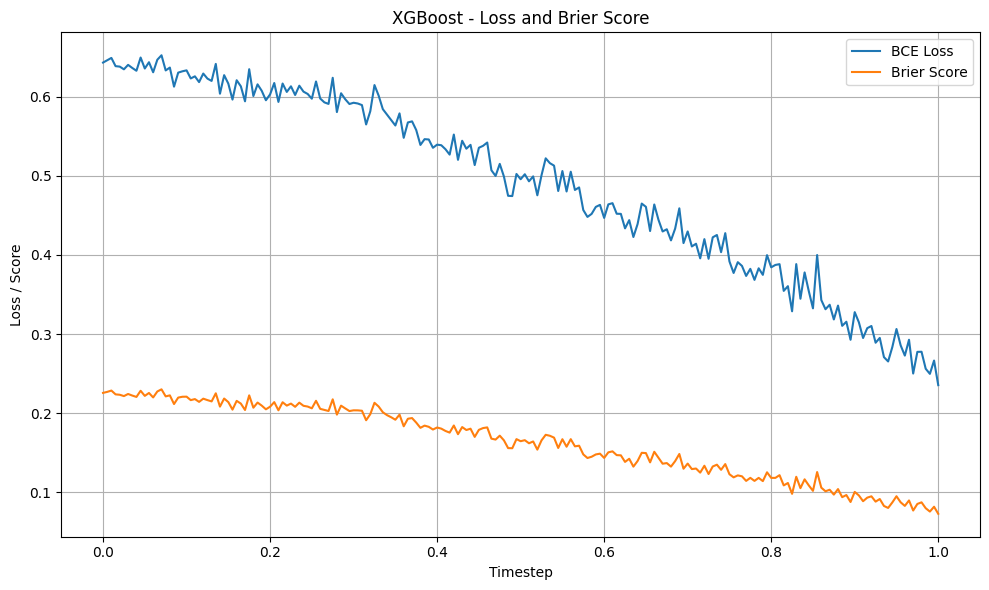

[0.6429326753016685, 0.645802976240625, 0.6487989169838333, 0.6384041222154238, 0.6378360336215411, 0.6344142126452272, 0.640028328955611, 0.6361184811083938, 0.6325947198689654, 0.6492970595817907, 0.6354263361976856, 0.6433766231961333, 0.6306794839594627, 0.6465366468841846, 0.6521662485337276, 0.633028484575397, 0.6366070150800398, 0.6125216880040855, 0.6302234178217297, 0.6319001268556422, 0.6331138105356829, 0.622899680106774, 0.6255615387078741, 0.6182719838488878, 0.6290590172217847, 0.6227001949450403, 0.6197417166337597, 0.6412752854175627, 0.6035827937779601, 0.6270372461100959, 0.6163481754271478, 0.596187279803304, 0.6206224590135164, 0.6129498063909525, 0.5939912338172043, 0.6345512767375951, 0.6006852777432784, 0.6154363407469392, 0.6072761256495817, 0.5953615924848817, 0.6027363397899291, 0.6171093823823773, 0.5932284884527536, 0.6164591154634965, 0.6058591327641508, 0.6129437626942753, 0.6019902840557336, 0.6137190575050236, 0.6062260115376567, 0.6033060242838356, 0.59

In [63]:
import process_data
modules_to_reload = [
    'process_data',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

x1 = process_data.plot_loss(models, test_data, "XGBoost")

In [65]:
np.array(x1["losses"]) - np.array(x2["losses"])

array([-9.15144214e-04,  3.03330522e-03,  3.35819029e-04, -6.99282894e-04,
       -1.95585560e-03, -6.98473196e-03, -6.08646549e-04, -1.57416488e-03,
        7.53434443e-04,  1.32979103e-03, -1.48434961e-03, -2.14679331e-03,
       -6.61157506e-03, -4.33815628e-03, -1.44056719e-03, -4.35750605e-03,
        1.96792236e-03, -6.31379585e-04,  3.60770921e-03,  2.75927900e-03,
        1.33431975e-03,  4.12296414e-03,  6.69427391e-03,  2.66355675e-03,
        4.82926042e-03,  4.85374299e-03, -5.36593215e-03,  1.05579834e-02,
        1.02217246e-02,  2.10049555e-03,  1.36378948e-03,  1.32914444e-04,
        1.73585586e-03, -5.07420121e-03, -4.64088754e-03, -2.43057986e-03,
       -2.50478399e-03, -1.74325304e-03, -1.47392853e-03, -1.83186709e-03,
        4.07832183e-04, -3.55571118e-03, -1.61797494e-03,  5.51553671e-03,
        7.55664850e-03,  2.09082087e-03,  1.42625528e-03,  2.63476897e-03,
       -2.19020933e-03, -5.89513410e-03,  2.40645806e-03,  1.73995623e-03,
        4.61164903e-03, -

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
features = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.downNeg", "end.distanceNeg", "end.yardsToEndzoneNeg", "home_timeouts_left", "away_timeouts_left", "predicted_drive_points_ev"]

def is_close_to_scoring(row, home_has_possession, score_difference):
    yards_to_endzone = abs(row[features.index("end.yardsToEndzoneNeg")])
    down = abs(row[features.index("end.down")])

    # score_difference = home_score - away_score
    # if score_difference > 0: home is winning, away is trailing
    # if score_difference < 0: home is trailing
    if score_difference > 0:
        trailing_has_ball = (home_has_possession == 0)
    else:
        trailing_has_ball = (home_has_possession == 1)

    if not trailing_has_ball:
        return False

    # Trailing team has the ball - check field position
    in_td_range = yards_to_endzone <= 25
    in_fg_range = yards_to_endzone <= 40 and down >= 3
    return in_td_range or in_fg_range


def find_edge_cases(test_data, features, timestep_threshold=0.97, max_score_diff=7):
    """
    Extract edge cases from the test dataset.
    An edge case is an endgame play where:
      1. game_completed >= timestep_threshold (endgame)
      2. |score_difference| < max_score_diff (close game, strictly less than 7)
      3. The trailing team is close to scoring (heuristic based on field position)
    Returns a list of (feature_row, label, homeWinProbability) tuples.
    """
    edge_cases = []
    for timestep_key, entries in test_data.items():
        for entry in entries:
            row = entry["rows"]
            label = entry["label"]
            hwp = entry.get("homeWinProbability", None)

            game_completed = row[features.index("game_completed")]
            score_diff = row[features.index("score_difference")]
            home_poss = row[features.index("home_has_possession")]

            # Condition 1: endgame
            if game_completed < timestep_threshold:
                continue

            # Condition 2: close game (strictly less than 7 points difference)
            if abs(score_diff) >= max_score_diff:
                continue

            # Condition 3: trailing team is close to scoring
            if score_diff == 0:
                # Tied game: whoever has ball in scoring position is an edge case
                yards_to_endzone = abs(row[features.index("end.yardsToEndzoneNeg")])
                down = abs(row[features.index("end.downNeg")])
                if not (yards_to_endzone <= 25 or (yards_to_endzone <= 40 and down >= 3)):
                    continue
            else:
                if not is_close_to_scoring(row, home_poss, score_diff):
                    continue

            edge_cases.append((row, label, hwp))

    return edge_cases


def predict_edge_cases(edge_cases, models, features):
    """
    Run inference on extracted edge cases.
    edge_cases: list of (feature_row, label, homeWinProbability)
    Prints P(home win), ESPN homeWinProbability, and ground truth label.
    """
    model_keys = sorted(models.keys())
    brier_sum = 0.0
    espn_brier_sum = 0.0
    n_features = len(features)

    for row, label, hwp in edge_cases:
        timestep = row[features.index("game_completed")]

        key = max((k for k in model_keys if k <= timestep), default=model_keys[0])
        model = models[key]

        # Use only the model features (first n_features values), exclude homeWinProbability
        feature_input = row[:n_features].reshape(1, -1)
        prob = model.predict_proba(feature_input)[0][1]
        brier_sum += (prob - label) ** 2

        hwp_str = f"{hwp:.4f}" if hwp is not None else "N/A"
        if hwp is not None:
            espn_brier_sum += (hwp - label) ** 2
        print(
            f"score_diff={row[features.index('score_difference')]:+.0f}  "
            f"home_poss={int(row[features.index('home_has_possession')])}  "
            f"yards_to_ez={row[features.index('end.yardsToEndzoneNeg')]:.1f}  "
            f"down={int(row[features.index('end.downNeg')])}  "
            f"game_completed={row[features.index('game_completed')]:.3f}  "
            f"| P(Home win)={prob:.4f}  "
            f"ESPN={hwp_str}  "
            f"GT={label:.0f}"
        )

    brier_score = brier_sum / len(edge_cases) if edge_cases else float("nan")
    print(f"\n{'='*70}")
    print(f"Total edge cases found: {len(edge_cases)}")
    print(f"Brier Score (vs GT):    {brier_score:.4f}")
    print(f"ESPN Brier Score (vs GT): {espn_brier_sum / len(edge_cases) if edge_cases else float('nan'):.4f}")

# Find edge cases |in the test dataset and run inference
edge_cases_from_test = find_edge_cases(test_data, features, timestep_threshold=0.97, max_score_diff=7)
print(f"Found {len(edge_cases_from_test)} edge cases in test data.\n")
predict_edge_cases(edge_cases_from_test, models, features)


Found 660 edge cases in test data.

score_diff=+3  home_poss=0  yards_to_ez=-2.0  down=-2  game_completed=0.970  | P(Home win)=0.5915  ESPN=0.2705  GT=1
score_diff=+5  home_poss=0  yards_to_ez=-1.0  down=-2  game_completed=0.970  | P(Home win)=0.9206  ESPN=0.4119  GT=1
score_diff=+2  home_poss=0  yards_to_ez=-27.0  down=-3  game_completed=0.970  | P(Home win)=0.3770  ESPN=0.3788  GT=0
score_diff=+2  home_poss=0  yards_to_ez=-20.0  down=-1  game_completed=0.970  | P(Home win)=0.3602  ESPN=0.2911  GT=0
score_diff=+0  home_poss=1  yards_to_ez=15.0  down=1  game_completed=0.970  | P(Home win)=0.8609  ESPN=0.4155  GT=0
score_diff=+6  home_poss=0  yards_to_ez=-1.0  down=-3  game_completed=0.970  | P(Home win)=0.8597  ESPN=0.6887  GT=1
score_diff=+6  home_poss=0  yards_to_ez=-1.0  down=-2  game_completed=0.970  | P(Home win)=0.8616  ESPN=0.4802  GT=1
score_diff=+0  home_poss=1  yards_to_ez=23.0  down=1  game_completed=0.971  | P(Home win)=0.8418  ESPN=0.8125  GT=1
score_diff=+0  home_poss=1  

In [29]:
%reload_ext autoreload

In [34]:
from models.utils import SHAP_analysis


SHAP_analysis(models, training_data, test_data, "XGBoost", "shap_values/XGBoost", timesteps_size = 0.1, num_threads = 4)

Selected 11 timesteps on the grid before deduplication.
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Processing 11 timesteps (skipping 0 already done, 190 not selected).



ExactExplainer explainer:  26%|██▋       | 184/698 [00:00<?, ?it/s]


ExactExplainer explainer:  27%|██▋       | 187/698 [00:10<00:17, 28.72it/s]

ExactExplainer explainer:  27%|██▋       | 190/698 [00:10<00:24, 20.60it/s]


ExactExplainer explainer:  28%|██▊       | 193/698 [00:10<00:27, 18.13it/s]


ExactExplainer explainer:  28%|██▊       | 195/698 [00:10<00:28, 17.94it/s]


ExactExplainer explainer:  28%|██▊       | 197/698 [00:10<00:27, 18.03it/s]


ExactExplainer explainer:  29%|██▉       | 201/698 [00:10<00:27, 18.38it/s]

ExactExplainer explainer:  29%|██▉       | 203/698 [00:11<00:26, 18.71it/s]


ExactExplainer explainer:  30%|██▉       | 206/698 [00:11<00:26, 18.65it/s]


ExactExplainer explainer:  30%|██▉       | 208/698 [00:11<00:26, 18.71it/s]


ExactExplainer explainer:  30%|███       | 210/698 [00:11<00:26, 18.76it/s]


ExactExplainer explainer:  31%|███       | 213/698 [00:11<00:25, 19.07it/s]


ExactExplainer explainer:  31%|███       | 216/698 [00:11<00:24, 19.83it/

Saved XGBoost_0.0.npz


ExactExplainer explainer:  33%|███▎      | 229/698 [00:12<00:27, 17.24it/s]


ExactExplainer explainer:  33%|███▎      | 231/698 [00:12<00:28, 16.61it/s]


ExactExplainer explainer:  33%|███▎      | 233/698 [00:12<00:28, 16.26it/s]


ExactExplainer explainer:  34%|███▎      | 235/698 [00:12<00:27, 16.73it/s]


ExactExplainer explainer:  34%|███▍      | 237/698 [00:12<00:29, 15.89it/s]


ExactExplainer explainer:  35%|███▍      | 241/698 [00:13<00:27, 16.73it/s]


ExactExplainer explainer:  35%|███▍      | 243/698 [00:13<00:27, 16.39it/s]


ExactExplainer explainer:  35%|███▌      | 245/698 [00:13<00:27, 16.23it/s]


ExactExplainer explainer:  36%|███▌      | 248/698 [00:13<00:27, 16.36it/s]


ExactExplainer explainer:  36%|███▌      | 252/698 [00:13<00:27, 16.49it/s]




ExactExplainer explainer:  37%|███▋      | 256/698 [00:14<00:28, 15.42it/s]


ExactExplainer explainer:  37%|███▋      | 258/698 [00:14<00:28, 15.28it/s]


ExactExplainer explainer:  37%|███▋      | 260/698 [00:14<00:2

Saved XGBoost_0.3.npz


...

Saved XGBoost_0.9.npz


ExactExplainer explainer:  43%|████▎     | 1293/3037 [01:40<01:53, 15.40it/s]

ExactExplainer explainer:  43%|████▎     | 1295/3037 [01:40<01:45, 16.48it/s]

ExactExplainer explainer:  43%|████▎     | 1298/3037 [01:40<01:39, 17.47it/s]

ExactExplainer explainer:  43%|████▎     | 1300/3037 [01:40<01:38, 17.57it/s]

ExactExplainer explainer:  43%|████▎     | 1302/3037 [01:41<01:41, 17.06it/s]

ExactExplainer explainer:  43%|████▎     | 1304/3037 [01:41<01:44, 16.62it/s]

ExactExplainer explainer:  43%|████▎     | 1307/3037 [01:41<01:37, 17.82it/s]

ExactExplainer explainer:  43%|████▎     | 1309/3037 [01:41<01:37, 17.64it/s]

ExactExplainer explainer:  43%|████▎     | 1311/3037 [01:41<01:35, 17.99it/s]

ExactExplainer explainer:  43%|████▎     | 1313/3037 [01:41<01:39, 17.33it/s]



ExactExplainer explainer:  43%|████▎     | 1317/3037 [01:41<01:37, 17.68it/s]

ExactExplainer explainer:  43%|████▎     | 1319/3037 [01:42<01:47, 16.02it/s]



ExactExplainer explainer:  44%|████▎     | 1322/

Saved XGBoost_1.0.npz


ExactExplainer explainer: 3038it [02:54, 16.72it/s]                          


Saved XGBoost_0.5.npz


In [66]:
modules_to_reload = [
    'process_data',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

from process_data import write_predictions

write_predictions(models, interpolated_dir, [2024, 2025], 0, features, replace_nan_val = 0, phat_b = "xgboost_phat_b")

Loading data for 2025
Processed file:  game_401772888.csv
Processed file:  game_401772863.csv
Processed file:  game_401772877.csv
Processed file:  game_401772730.csv
Processed file:  game_401772724.csv
Processed file:  game_401772718.csv
Processed file:  game_401772917.csv
Processed file:  game_401772903.csv
Processed file:  game_401772902.csv
Processed file:  game_401772916.csv
Processed file:  game_401772719.csv
Processed file:  game_401772725.csv
Processed file:  game_401772731.csv
Processed file:  game_401772876.csv
Processed file:  game_401772862.csv
Processed file:  game_401772889.csv
Processed file:  game_401772848.csv
Processed file:  game_401772874.csv
Processed file:  game_401772860.csv
Processed file:  game_401772727.csv
Processed file:  game_401772733.csv
Processed file:  game_401772928.csv
Processed file:  game_401772900.csv
Processed file:  game_401772914.csv
Processed file:  game_401772915.csv
Processed file:  game_401772901.csv
Processed file:  game_401772929.csv
Proces

In [67]:
import os
import shutil

# Define the ancestor directory and the parent directory
src_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dest_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))

# Specify a list of directories to copy
sources = [
    os.path.join(src_dir, "dataset_interpolated_fixed", "2024"),
    os.path.join(src_dir, "dataset_interpolated_fixed", "2025")
]

destination = os.path.join(dest_dir, "test_final", "xgboost_model")

# Iterate through each source and copy
for source in sources:
    if os.path.exists(source):
        # Extract the year/folder name from source
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)
        print(f"Copied '{source}' to '{destination}'")
    else:
        print(f"Source '{source}' does not exist")

Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2024' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/xgboost_model'
Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2025' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/xgboost_model'
